In [3]:
print(R.version$version.string)

[1] "R version 4.6.1 (2026-06-24 ucrt)"


In [156]:
suppressPackageStartupMessages({
    library("ape")
    library("phytools")
    library("corHMM")
    library("OUwie")
    library("readxl")
    library("ggplot2")
    library("gridExtra")
})
source("../houwie_patches.R") # this contains patched versions of OUwie::getModelTable and OUwie::getModelAvgParams

read_all_rds <- function(dirpath, cd, strip, rm_underscores = TRUE) {
    # dirpath = path to the directory containing the .Rds files
    # cd = character dependent or independent models, these are expected to contain "CD" or "CID" in their names
    # strip = the regex pattern to strip out of the file names when naming objects, can be a plain string as well
    # rm_underscores - strip all the underscores in the object name

    fnames <- list.files(dirpath) # all the files in the specified dir
    if(cd) fnames <- fnames[grep(pattern = "CD", fnames)]
    else fnames <- fnames[grep(pattern = "CID", fnames)] # cherry pick CD or CID models, given their names contain "CD" or "CID" to distinguish them
    # print(fnames)

    paths <- paste0(dirpath, fnames) # relative paths for all the Rds files
    stopifnot(length(fnames)==length(paths))

    # remove the unnecessary parts of the file names to create the model names and also remove all the underscores
    mnames <- fnames |> gsub(pattern = ".Rds", replacement = '') |> gsub(pattern = strip, replacement = '') |> gsub(pattern = ifelse(rm_underscores, '_', ''), replacement = '')
    stopifnot(length(fnames)==length(mnames))
    stopifnot(length(paths)==length(mnames))

    models <- list()
    for (i in seq_along(mnames)) models[[mnames[i]]] <- readRDS(file = paths[i])
    stopifnot(length(models)==length(mnames))

    models
}

In [11]:
packageVersion("OUwie")

[1] '3.0.3'

In [12]:
packageVersion("corHMM")

[1] '2.8'

In [13]:
fred4 <- read.csv("../../data/chapter2/FRED/subsets/continuous_raw.csv")
s <- readxl::read_xlsx("../../data/chapter2/FRED/subsets/final.xlsx", sheet = "final")[c("binominal", "state")]
s$binominal <- gsub(s$binominal, pattern = ' ', replacement = '_')
fred4 <- merge(fred4, s, by = "binominal", all.x = TRUE)

In [14]:
fred4[!duplicated(fred4$binominal), "state"] |> table()


   AM   EcM EcMAM   ErM    NM  NMAM 
 1098   120    20     9    16    38 

# ___Hypotheses___

- Evolution of mycorrhizal states and fine root ecological strategies will be correlated. We expect that RD, SRL and RTD will show correlated evolution with mycorrhizal states (__overall character dependency - if found, show what OU parameters show mycorrhizal state dependent signals__).
  
- Evolutionary rates of the fine root traits ($\sigma^2$) would be higher when they are paired to a hybrid (dual) mycorrhizal state (e.g. AM/NM, AM/EcM) than a singular mycorrhizal state (e.g. AM, EcM). 
  
- Evolutionary rate ($\sigma^2$) of fine root traits should be the lowest when paired to NM.

__Can also add the pull towards the optima ($\theta$) - $\alpha$ to the last two hypotheses.__

In [19]:
# these models were all fit with 250 simmaps, a phylogeny of 1301 plant species including ErM species
# these models were fit using the following template

```R
OUwie::hOUwie(phy = phylogeny,
              data = data,
              rate.cat = 2 if null_model else 1,
              discrete_model = discrete_model,
              continuous_model = continuous_model,
              nSim = 250,
              null.model = TRUE if null_model else FALSE,
              lb_discrete_model = 1e-15,
              ub_discrete_model = 10.000,
              lb_continuous_model = c(lb_continuous_model.alpha, lb_continuous_model.sigma_sq, lb_continuous_model.theta), # these were set to defaults
              ub_continuous_model = c(ub_continuous_model.alpha, ub_continuous_model.sigma_sq, ub_continuous_model.theta) # these were set to defaults
)
```

## ___Root diameter___
------------------

In [15]:
rd_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/F00679/", cd = TRUE, strip = "_F00679_CD_250")
rd_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/F00679/", cd = FALSE, strip = "_F00679_CID_250")

In [16]:
merge(OUwie::getModelTable(rd_cd, type = "AICc")[c("AICc", "dAICc")], OUwie::getModelTable(rd_cid, type = "AICc")[c("AICc", "dAICc")], by = 0, all = TRUE, suffixes = c("_CD", "_CID"))

Row.names,AICc_CD,dAICc_CD,AICc_CID,dAICc_CID
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,156566.78,129654.769,221312.34,208582.4252
ARDOUMA,225011.14,198099.123,46352.32,33622.4039
ARDOUMV,1021122.13,994210.116,241934.92,229204.9964
ARDOUMVA,4797144.25,4770232.240,12729.92,0.0000
EROUM,392226.26,365314.252,721766.58,709036.6637
EROUMA,600719.97,573807.953,18741.80,6011.8794
EROUMV,157222.52,130310.511,346898.80,334168.8801
EROUMVA,39762.09,12850.079,13224.63,494.7128
SYMOUM,296939.01,270026.993,346720.21,333990.2903


In [17]:
# issue with the current implementation - comes from getModelTable() line 739 - error check for number of models should go before the row mismatch error check
# in call to getModelTable inside getModelAvgParams at line 787 (after dropping the failed? models)
rd_cd_avgs <- OUwie::getModelAvgParams(rd_cd, type = "AICc", force = FALSE)

ERROR: Error in if (var(unlist(lapply(model.list, function(x) dim(x$data)[1]))) != : missing value where TRUE/FALSE needed


In [19]:
rd_cd_avgs <- getModelAvgParams_patched(rd_cd, type = "AICc", force = FALSE)
rd_cid_avgs <- getModelAvgParams_patched(rd_cid, type = "AICc", force = FALSE)

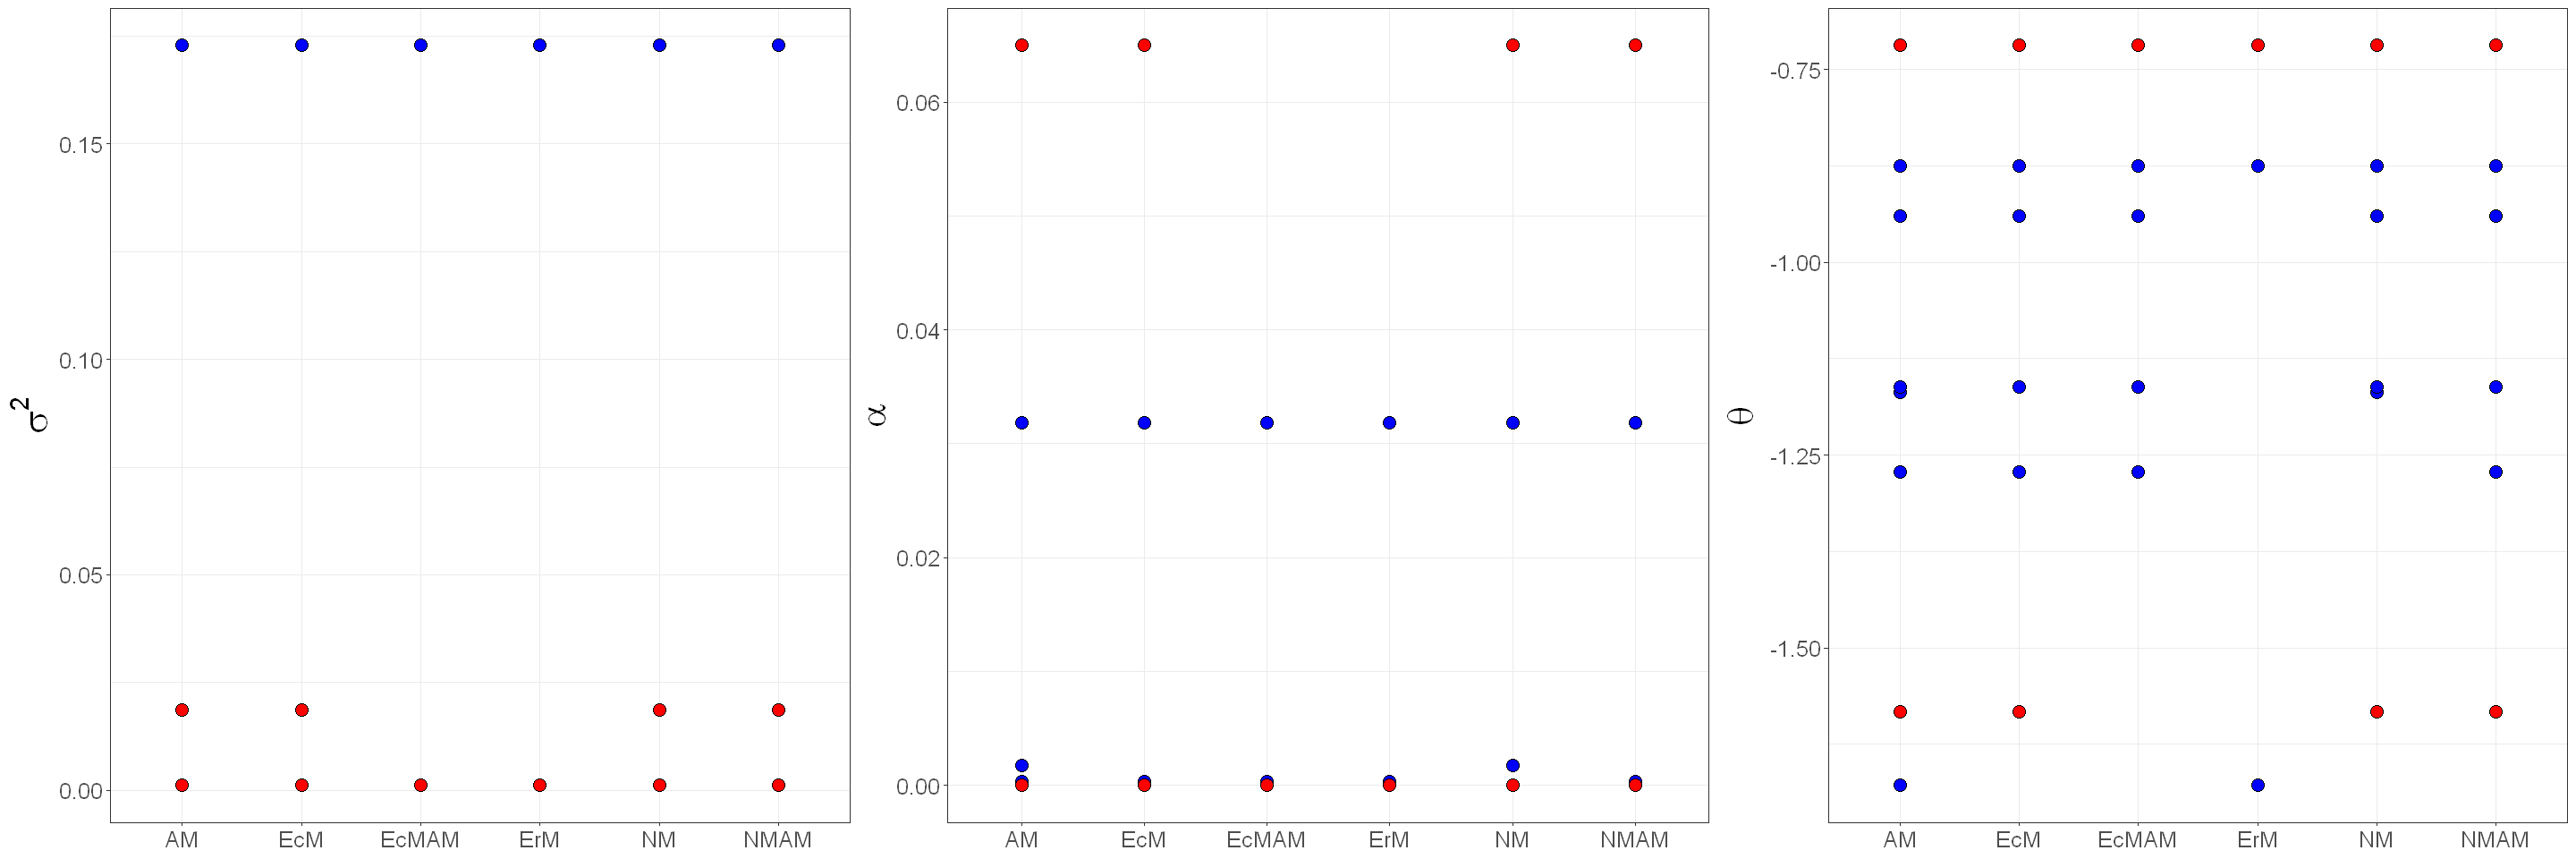

In [157]:
p1 <-   ggplot() + 
        geom_point(data = rd_cd_avgs, aes(x = tip_state, y = sigma.sq), fill = "blue", shape = 21, show.legend = FALSE, size = 4) + # CD
        geom_point(data = rd_cid_avgs, aes(x = tip_state, y = sigma.sq), fill = "red", shape = 21, show.legend = FALSE, size = 4) + # CID
        xlab(NULL) +
        ylab(expression(sigma^2)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p2 <-   ggplot() + 
        geom_point(data = rd_cd_avgs, aes(x = tip_state, y = alpha), fill = "blue", shape = 21, show.legend = FALSE, size = 4) +
        geom_point(data = rd_cid_avgs, aes(x = tip_state, y = alpha), fill = "red", shape = 21, show.legend = FALSE, size = 4) +
        xlab(NULL) +
        ylab(expression(alpha)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p3 <-   ggplot() + 
        geom_point(data = rd_cd_avgs, aes(x = tip_state, y = theta), fill = "blue", shape = 21, show.legend = FALSE, size = 4) +
        geom_point(data = rd_cid_avgs, aes(x = tip_state, y = theta), fill = "red", shape = 21, show.legend = FALSE, size = 4) +
        xlab(NULL) +
        ylab(expression(theta)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

options(repr.plot.width = 24, repr.plot.height = 8)
gridExtra::grid.arrange(p1, p2, p3, nrow =1)

## ___Specific Root Length___
-------------------

In [136]:
srl_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/F00727/", cd = TRUE, strip = "_F00727_CD_250")
srl_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/F00727/", cd = FALSE, strip = "_F00727_CID_250")

In [138]:
merge(OUwie::getModelTable(srl_cd, type = "AICc")[c("AICc", "dAICc")], OUwie::getModelTable(srl_cid, type = "AICc")[c("AICc", "dAICc")], by = 0, all = TRUE, suffixes = c("_CD", "_CID"))

Row.names,AICc_CD,dAICc_CD,AICc_CID,dAICc_CID
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,1821366.64,1790470.49,3550202.73,3535003.9653
ARDOUMA,47890.81,16994.66,15198.76,0.0000
ARDOUMV,5010581.59,4979685.44,4134546.69,4119347.9289
ARDOUMVA,756736.59,725840.44,15628.59,429.8281
EROUM,2356011.61,2325115.46,2098042.47,2082843.7046
EROUMA,30896.15,0.00,29917.89,14719.1293
EROUMV,129741.38,98845.23,2824643.33,2809444.5685
EROUMVA,2905113.54,2874217.39,74030.38,58831.6189
SYMOUM,728740.34,697844.19,856474.87,841276.1130


In [137]:
srl_cd_avgs <- getModelAvgParams_patched(srl_cd, type = "AICc", force = FALSE)
srl_cid_avgs <- getModelAvgParams_patched(srl_cid, type = "AICc", force = FALSE)

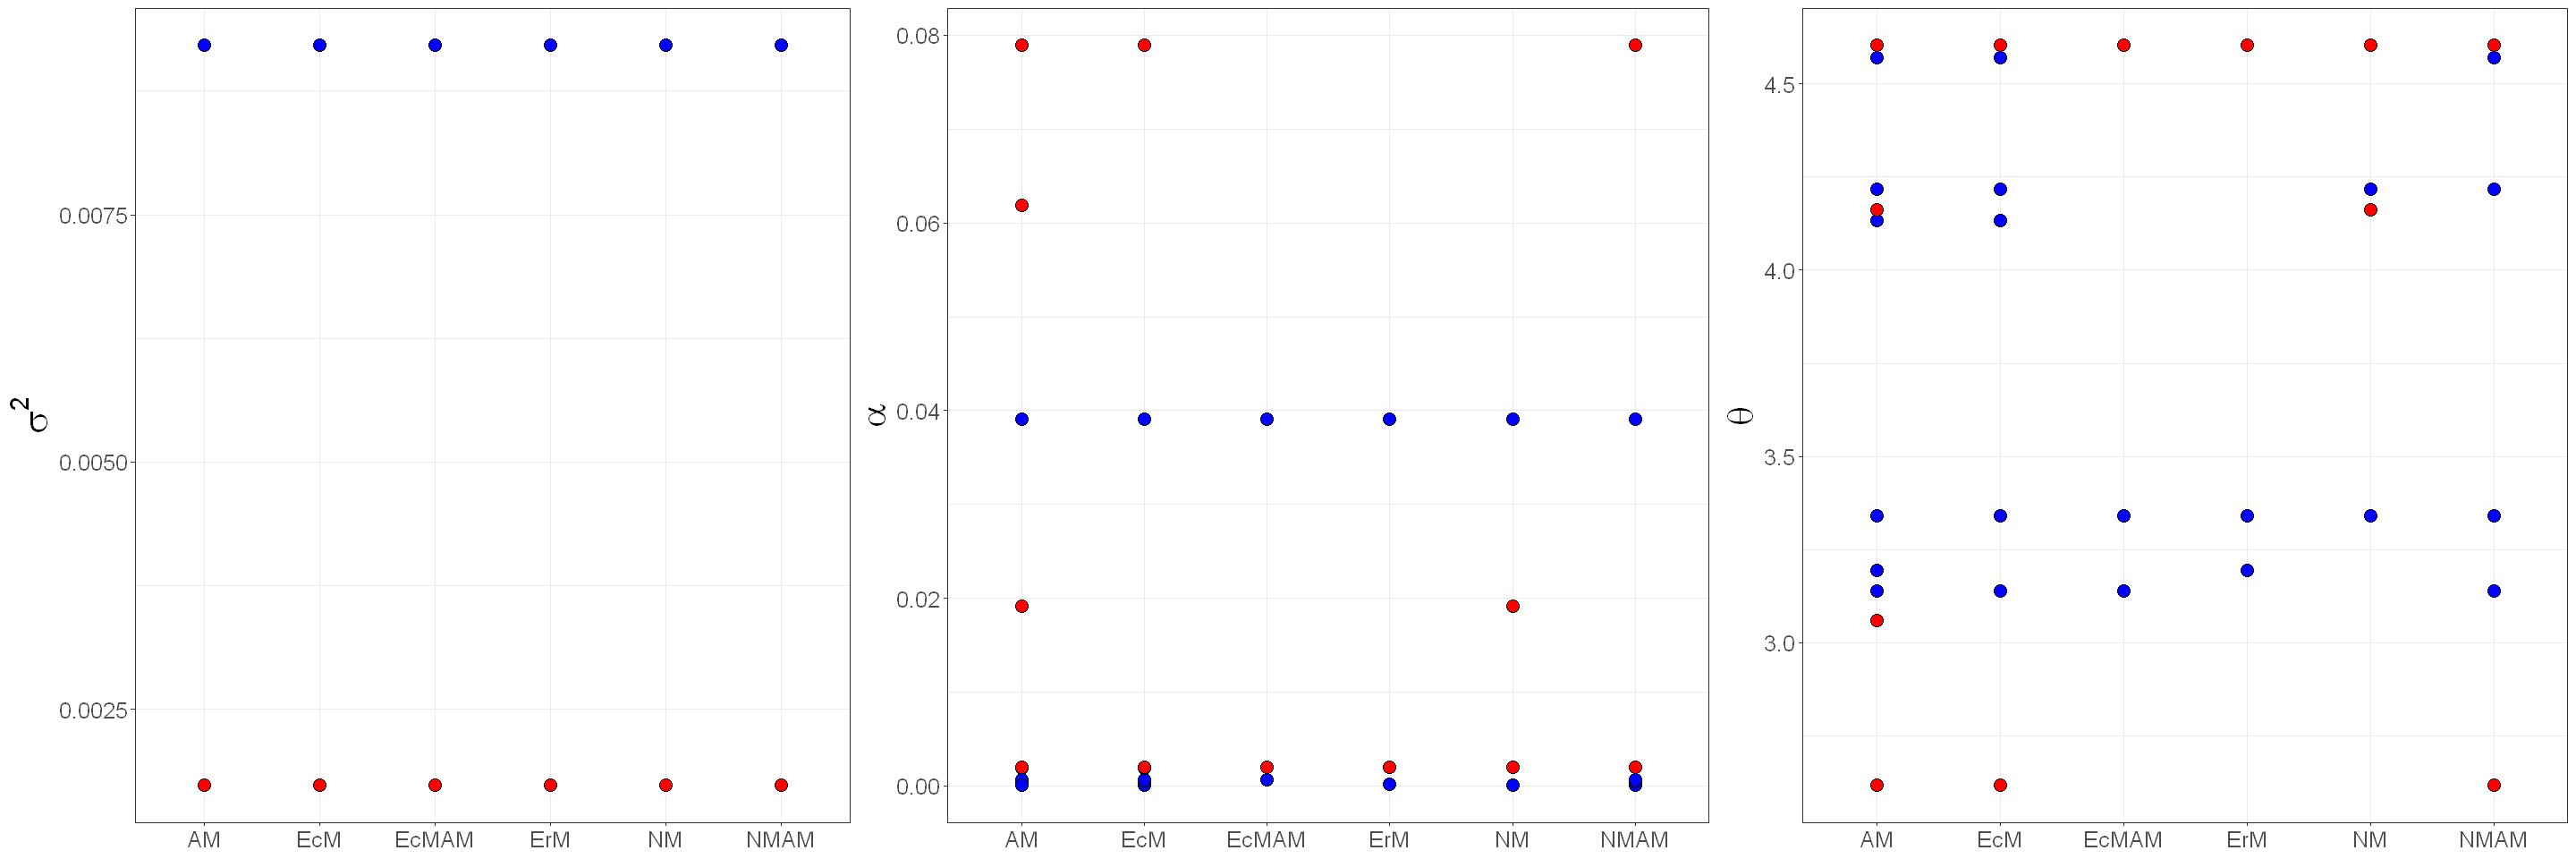

In [158]:
p1 <-   ggplot() + 
        geom_point(data = srl_cd_avgs, aes(x = tip_state, y = sigma.sq), fill = "blue", shape = 21, show.legend = FALSE, size = 4) + # CD
        geom_point(data = srl_cid_avgs, aes(x = tip_state, y = sigma.sq), fill = "red", shape = 21, show.legend = FALSE, size = 4) + # CID
        xlab(NULL) +
        ylab(expression(sigma^2)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p2 <-   ggplot() + 
        geom_point(data = srl_cd_avgs, aes(x = tip_state, y = alpha), fill = "blue", shape = 21, show.legend = FALSE, size = 4) + # CD
        geom_point(data = srl_cid_avgs, aes(x = tip_state, y = alpha), fill = "red", shape = 21, show.legend = FALSE, size = 4) + # CID
        xlab(NULL) +
        ylab(expression(alpha)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p3 <-   ggplot() + 
        geom_point(data = srl_cd_avgs, aes(x = tip_state, y = theta), fill = "blue", shape = 21, show.legend = FALSE, size = 4) + # CD
        geom_point(data = srl_cid_avgs, aes(x = tip_state, y = theta), fill = "red", shape = 21, show.legend = FALSE, size = 4) + # CID
        xlab(NULL) +
        ylab(expression(theta)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

options(repr.plot.width = 24, repr.plot.height = 8)
gridExtra::grid.arrange(p1, p2, p3, nrow =1)

## ___Root Tissue Density___
----------------------

In [142]:
rtd_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/F00709/", cd = TRUE, strip = "_F00709_CD_250")
rtd_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/F00709/", cd = FALSE, strip = "_F00709_CID_250")

In [143]:
merge(OUwie::getModelTable(rtd_cd, type = "AICc")[c("AICc", "dAICc")], OUwie::getModelTable(rtd_cid, type = "AICc")[c("AICc", "dAICc")], by = 0, all = TRUE, suffixes = c("_CD", "_CID"))

Row.names,AICc_CD,dAICc_CD,AICc_CID,dAICc_CID
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,1.205219e+06,18347974422,547714.77,533680.769
ARDOUMA,4.171361e+04,18346810917,476646.98,462612.977
ARDOUMV,6.109132e+05,18347380116,1196268.85,1182234.844
ARDOUMVA,3.063085e+06,18349832288,15357.18,1323.183
EROUM,7.556904e+05,18347524893,861410.60,847376.596
EROUMA,2.250686e+04,18346791710,14229.77,195.767
EROUMV,9.045598e+05,18347673763,82531.30,68497.301
EROUMVA,2.356864e+04,18346792772,20160.12,6126.122
SYMOUM,3.298568e+05,18347099060,332034.03,318000.026


In [ ]:
# SYMOUMVA CD - failed convergence

In [144]:
rtd_cd_avgs <- getModelAvgParams_patched(rtd_cd, type = "AICc", force = FALSE)
rtd_cid_avgs <- getModelAvgParams_patched(rtd_cid, type = "AICc", force = FALSE)

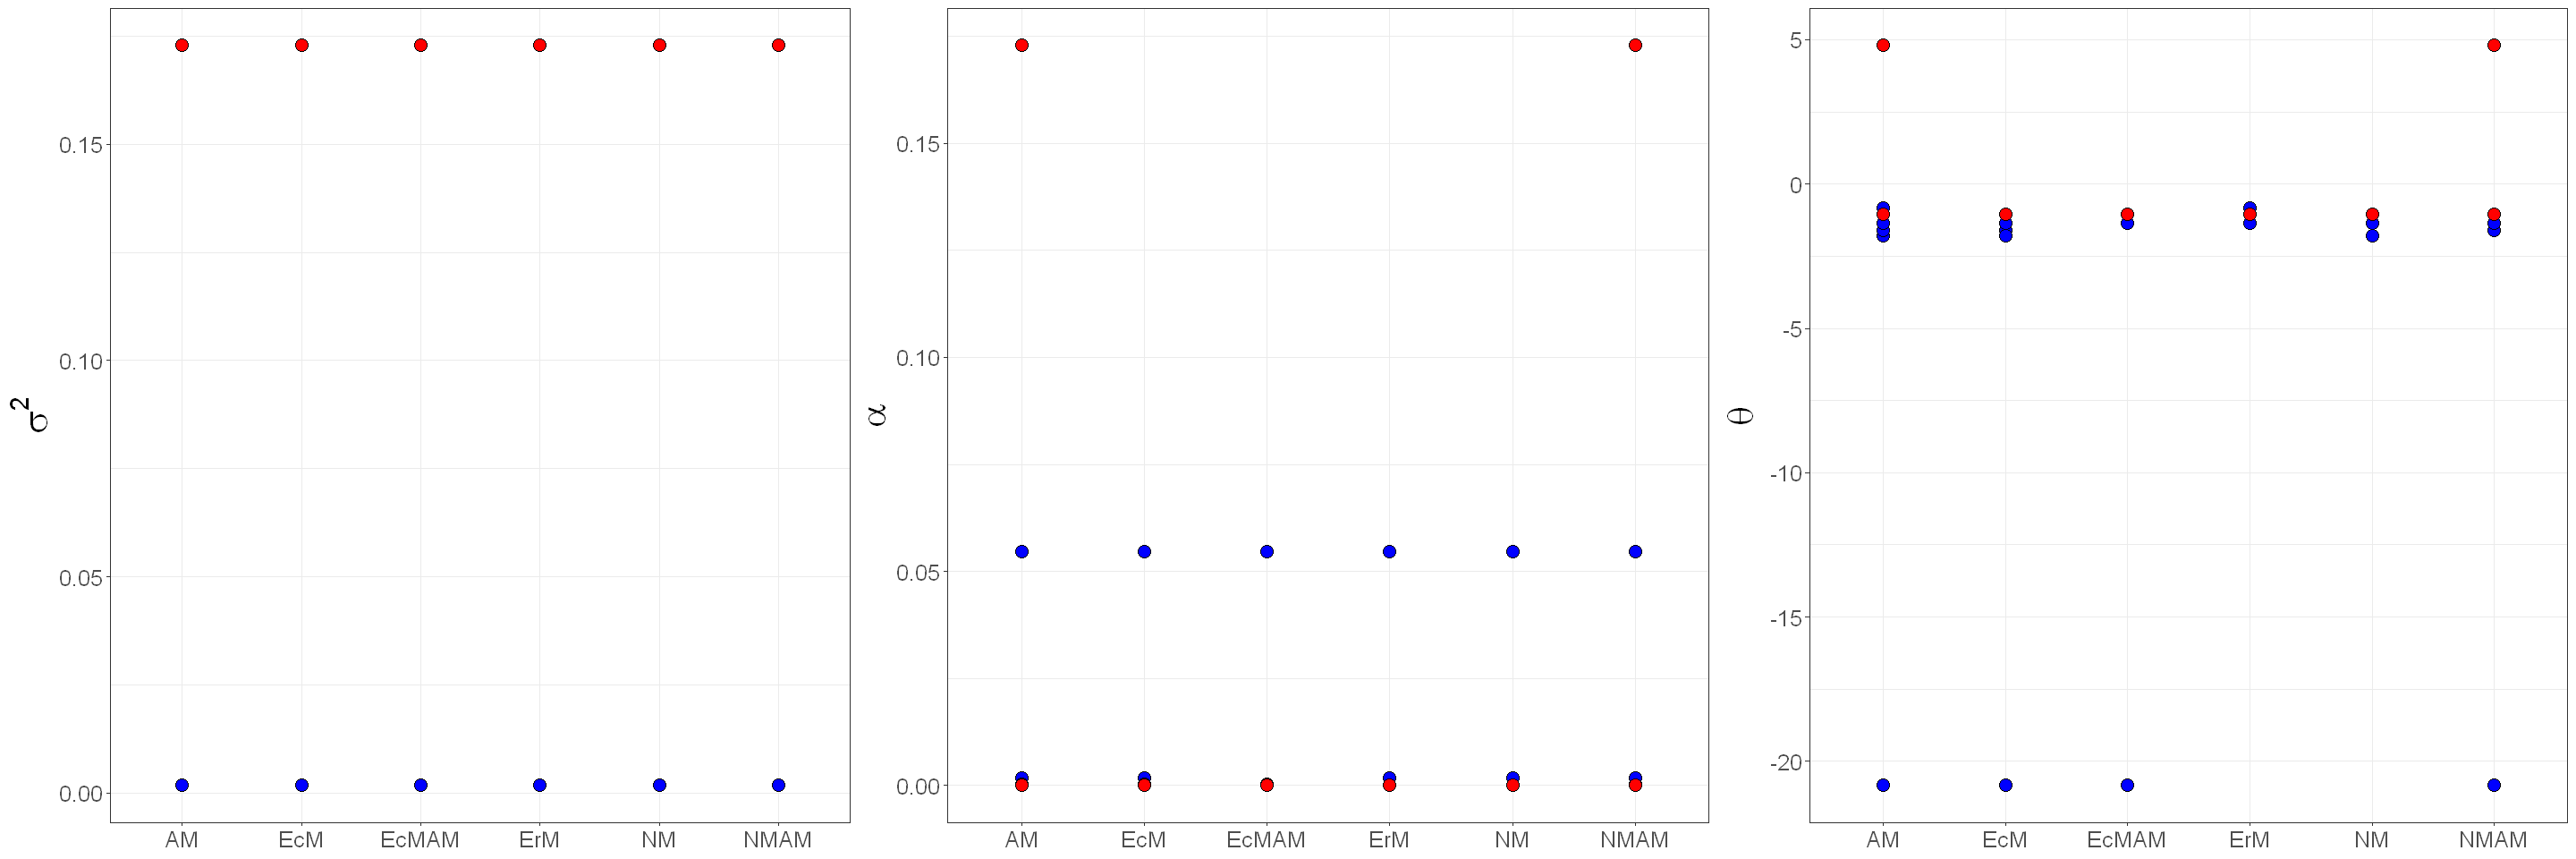

In [159]:
p1 <-   ggplot() + 
        geom_point(data = rtd_cd_avgs, aes(x = tip_state, y = sigma.sq), fill = "blue", shape = 21, show.legend = FALSE, size = 4) + # CD
        geom_point(data = rtd_cid_avgs, aes(x = tip_state, y = sigma.sq), fill = "red", shape = 21, show.legend = FALSE, size = 4) + # CID
        xlab(NULL) +
        ylab(expression(sigma^2)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p2 <-   ggplot() + 
        geom_point(data = rtd_cd_avgs, aes(x = tip_state, y = alpha), fill = "blue", shape = 21, show.legend = FALSE, size = 4) + # CD
        geom_point(data = rtd_cid_avgs, aes(x = tip_state, y = alpha), fill = "red", shape = 21, show.legend = FALSE, size = 4) + # CID
        xlab(NULL) +
        ylab(expression(alpha)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p3 <-   ggplot() + 
        geom_point(data = rtd_cd_avgs, aes(x = tip_state, y = theta), fill = "blue", shape = 21, show.legend = FALSE, size = 4) + # CD
        geom_point(data = rtd_cid_avgs, aes(x = tip_state, y = theta), fill = "red", shape = 21, show.legend = FALSE, size = 4) + # CID
        xlab(NULL) +
        ylab(expression(theta)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

options(repr.plot.width = 24, repr.plot.height = 8)
gridExtra::grid.arrange(p1, p2, p3, nrow =1)

## ___Questions___
-----------------

In [ ]:
# the "CID" models in this work (rate.cat = 2, null.model = TRUE) are these "CID" or "HYB" as these terms were used in the seed dispersal paper?


# if a "CID" model is best for all the traits - is it sensible to show their parameter averages in the results? since these aren't related to mycorrhizal states but hidden states - which aren't related to our hypotheses?

## ___Fine Root Pools & `hOUwie`___
-------------------------

In [129]:
# fine root definition affecting results:

# these are species trait averages for the same set of species in FRED 4.0 with two different criteria to define fine roots
# columns with an 'O' suffix - root order <= 3
# columns with a 'D' suffix - root diameter <= 2.00 mm

finerootcomp <- read.csv("./../../data/chapter2/FRED/subsets/fineroot-comparison.csv")[, -11] 
head(finerootcomp)

,binominal,F01286,F01289,F00679D,F00727D,F00709D,F00679O,F00727O,F00709O,state
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1,Abies nephrolepis,Abies,Pinaceae,-0.8789147,3.297534,-1.2740166,-0.8789147,3.297534,-1.2740166,EcM
2,Acacia auriculiformis,Acacia,Fabaceae,-0.7110736,3.620422,-1.2264457,-0.9535514,3.985692,-1.3093333,EcMAM
3,Acacia crassicarpa,Acacia,Fabaceae,-1.4875301,4.684720,-1.0216512,-1.4875301,4.684720,-1.0216512,EcMAM
4,Acacia mangium,Acacia,Fabaceae,-1.3761460,4.597037,-1.2378744,-1.3761460,4.597037,-1.2378744,EcMAM
5,Acer barbinerve,Acer,Sapindaceae,-1.3771364,4.967581,-1.8784367,-1.3771364,4.967581,-1.8784367,AM
6,Acer campbellii,Acer,Sapindaceae,-1.6620479,4.370364,-0.7874579,-1.6620479,4.370364,-0.7874579,AM


In [132]:
cor(finerootcomp$F00679D, finerootcomp$F00679O, method = "pearson") # RD

[1] 0.9479876

In [133]:
cor(finerootcomp$F00727D, finerootcomp$F00727O, method = "pearson") # SRL

[1] 0.9893136

In [134]:
cor(finerootcomp$F00709D, finerootcomp$F00709O, method = "pearson") # RTD

[1] 0.9748312

In [151]:
# but hOUwie results are very different - example RD

In [152]:
# root order based cutoff
rd_order_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679O/", cd = TRUE, strip = "_F00679O_CD_200")
rd_order_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679O/", cd = FALSE, strip = "_F00679O_CID_200")

# root diameter based cutoff
rd_diameter_cd <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp//F00679D/", cd = TRUE, strip = "_F00679D_CD_200")
rd_diameter_cid <- read_all_rds(dirpath = "../../data/chapter2/rdata/parallel/hie-general3/fineroots-comp/F00679D/", cd = FALSE, strip = "_F00679D_CID_200")

In [160]:
# comparing the CD fits from both pools
merge(OUwie::getModelTable(rd_order_cd, type = "AICc")[c("AICc", "dAICc")], OUwie::getModelTable(rd_diameter_cd, type = "AICc")[c("AICc", "dAICc")], by = 0, all = TRUE, suffixes = c("_order", "_diameter"))

Row.names,AICc_order,dAICc_order,AICc_diameter,dAICc_diameter
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,1046.341,0.00000,1359.014,163.0900
ARDOUMA,1476.868,430.52645,2787.785,1591.8610
ARDOUMV,4256.846,3210.50482,1318.745,122.8203
ARDOUMVA,1276.143,229.80123,4316.879,3120.9550
EROUM,21453.874,20407.53257,4171.651,2975.7268
EROUMA,3878.766,2832.42486,1195.924,0.0000
EROUMV,1083.133,36.79167,10650.296,9454.3714
EROUMVA,1261.681,215.33939,15541.251,14345.3262
SYMOUM,128935.993,127889.65175,1344.107,148.1824


In [161]:
# comparing the CID fits from both pools
merge(OUwie::getModelTable(rd_order_cid, type = "AICc")[c("AICc", "dAICc")], OUwie::getModelTable(rd_diameter_cid, type = "AICc")[c("AICc", "dAICc")], by = 0, all = TRUE, suffixes = c("_order", "_diameter"))

Row.names,AICc_order,dAICc_order,AICc_diameter,dAICc_diameter
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
ARDOUM,1694.2838,719.0372,30713.654,29506.25287
ARDOUMA,2045.7971,1070.5505,1340.778,133.37726
ARDOUMV,3488.4364,2513.1897,285009.220,283801.81887
ARDOUMVA,2344.0130,1368.7663,57828.266,56620.86570
EROUM,975.2466,0.0000,490695.107,489487.70627
EROUMA,2322.7553,1347.5087,1532.076,324.67506
EROUMV,121970.6799,120995.4333,1207.401,0.00000
EROUMVA,2300.4404,1325.1937,2057.695,850.29456
SYMOUM,5007.7158,4032.4692,1294.351,86.95015


In [162]:
avg_order_cd <- getModelAvgParams_patched(rd_order_cd, type = "AICc", force = FALSE)
avg_order_cid <- getModelAvgParams_patched(rd_order_cid, type = "AICc", force = FALSE)

avg_diam_cd <- getModelAvgParams_patched(rd_diameter_cd, type = "AICc", force = FALSE)
avg_diam_cid <- getModelAvgParams_patched(rd_diameter_cid, type = "AICc", force = FALSE)

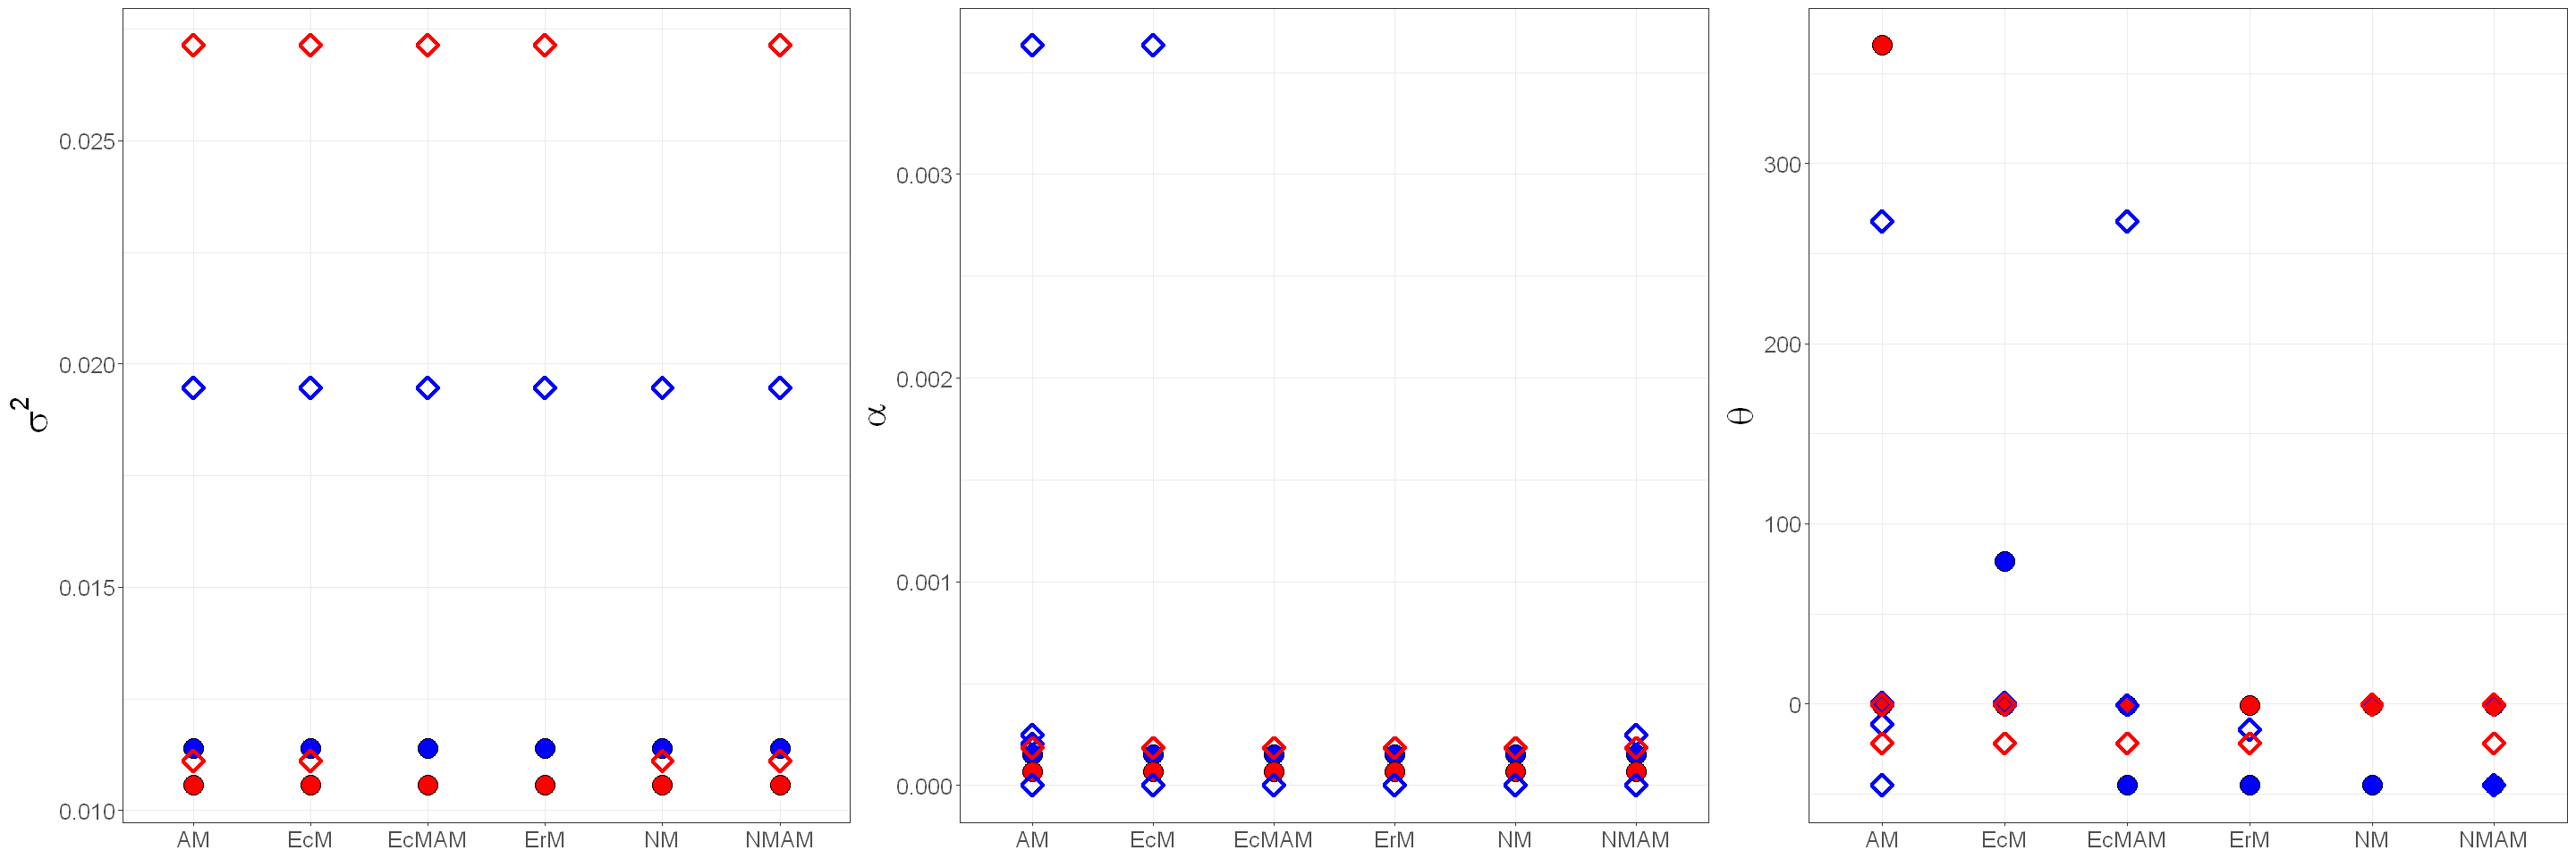

In [176]:
# circles for the order based averages and rotated square for the diameter based averages

p1 <-   ggplot() + 
        geom_point(data = avg_order_cd, aes(x = tip_state, y = sigma.sq), fill = "blue", shape = 21, show.legend = FALSE, size = 6) + 
        geom_point(data = avg_order_cid, aes(x = tip_state, y = sigma.sq), fill = "red", shape = 21, show.legend = FALSE, size = 6) + 
        geom_point(data = avg_diam_cd, aes(x = tip_state, y = sigma.sq), col = "blue", shape = 23, show.legend = FALSE, size = 4, stroke = 2) + 
        geom_point(data = avg_diam_cid, aes(x = tip_state, y = sigma.sq), col = "red", shape = 23, show.legend = FALSE, size = 4, stroke = 2) + 
        xlab(NULL) +
        ylab(expression(sigma^2)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p2 <-   ggplot() + 
        geom_point(data = avg_order_cd, aes(x = tip_state, y = alpha), fill = "blue", shape = 21, show.legend = FALSE, size = 6) + 
        geom_point(data = avg_order_cid, aes(x = tip_state, y = alpha), fill = "red", shape = 21, show.legend = FALSE, size = 6) +
        geom_point(data = avg_diam_cd, aes(x = tip_state, y = alpha), col = "blue", shape = 23, show.legend = FALSE, size = 4, stroke = 2) + 
        geom_point(data = avg_diam_cid, aes(x = tip_state, y = alpha), col = "red", shape = 23, show.legend = FALSE, size = 4, stroke = 2) + 
        xlab(NULL) +
        ylab(expression(alpha)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

p3 <-   ggplot() + 
        geom_point(data = avg_order_cd, aes(x = tip_state, y = theta), fill = "blue", shape = 21, show.legend = FALSE, size = 6) + 
        geom_point(data = avg_order_cid, aes(x = tip_state, y = theta), fill = "red", shape = 21, show.legend = FALSE, size = 6) +
        geom_point(data = avg_diam_cd, aes(x = tip_state, y = theta), col = "blue", shape = 23, show.legend = FALSE, size = 4, stroke = 2) + 
        geom_point(data = avg_diam_cid, aes(x = tip_state, y = theta), col = "red", shape = 23, show.legend = FALSE, size = 4, stroke = 2) +
        xlab(NULL) +
        ylab(expression(theta)) +
        theme_bw() + 
        theme(axis.text = element_text(size = 15), axis.title = element_text(size = 25))

options(repr.plot.width = 24, repr.plot.height = 8)
gridExtra::grid.arrange(p1, p2, p3, nrow =1)